# Exploratory Data Analysis

This notebook explores the Olist e-commerce dataset to understand
customer behavior, sales performance, products, sellers, payments,
delivery performance, and customer reviews.

## 1. Loading the Data

In [2]:
import pandas as pd

customers_df = pd.read_csv("../data/cleaned/customers_clean.csv")
orders_df = pd.read_csv("../data/cleaned/orders_clean.csv")
order_items_df = pd.read_csv("../data/cleaned/order_items_clean.csv")
order_payments_df = pd.read_csv("../data/cleaned/order_payments_clean.csv")
order_reviews_df = pd.read_csv("../data/cleaned/order_reviews_clean.csv")
products_df = pd.read_csv("../data/cleaned/products_clean.csv")
sellers_df = pd.read_csv("../data/cleaned/sellers_clean.csv")
geolocation_df = pd.read_csv("../data/olist_geolocation_dataset.csv")
product_category_name_translation_df = pd.read_csv(
    "../data/product_category_name_translation.csv"
)

## 2. Initial Dataset Overview

Before starting the analysis, the dimensions of each dataset are checked
to confirm that the expected data was loaded successfully.

In [3]:
print(f"{customers_df.shape} : customers_df")
print(f"{orders_df.shape} : orders_df")
print(f"{order_items_df.shape} : order_items_df")
print(f"{order_payments_df.shape} : order_payments_df")
print(f"{order_reviews_df.shape} : order_reviews_df")
print(f"{products_df.shape} : products_df")
print(f"{sellers_df.shape} : sellers_df")
print(f"{geolocation_df.shape} : geolocation_df")
print(f"{product_category_name_translation_df.shape} : product_category_name_translation_df")

(99441, 5) : customers_df
(99441, 8) : orders_df
(112650, 7) : order_items_df
(103886, 5) : order_payments_df
(99224, 7) : order_reviews_df
(32951, 9) : products_df
(3095, 4) : sellers_df
(1000163, 5) : geolocation_df
(71, 2) : product_category_name_translation_df


## 3. Orders Over Time

This section examines how order volume changed over time to identify
overall sales activity and temporal patterns in the marketplace.

### 3.1 Monthly Order Volume

To understand how order activity changed over time, the number of orders
is aggregated by month based on the purchase timestamp.

In [4]:
import datetime as dt

orders_df["order_purchase_timestamp"] = pd.to_datetime(orders_df["order_purchase_timestamp"])

monthly_orders = orders_df.groupby(orders_df["order_purchase_timestamp"].dt.to_period("M")).size()

monthly_orders

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

### 3.2 Monthly Order Volume Visualization

The monthly order volume is visualized to make the overall trend and
changes in marketplace activity easier to interpret.

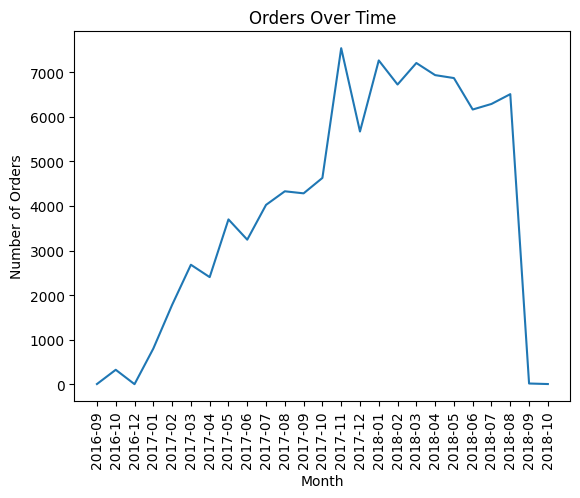

In [5]:
import matplotlib.pyplot as plt

plt.plot(monthly_orders.index.astype(str), monthly_orders.values)

plt.title("Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=90)

plt.show()

### Insight

- Order volume increased substantially from 2017 to 2018.
- Monthly orders reached their highest level in late 2017 and early 2018.
- Order volume remained relatively high throughout most of 2018, with some month-to-month fluctuations.
- The very low order counts at the beginning and end reflect the partial periods covered by the dataset.

## 4. Sales Performance

This section examines sales performance by analyzing order item prices
and freight values to understand the overall revenue generated by the
marketplace.

### 4.1 Total Sales

The total value of order items is calculated to estimate the overall
sales generated through the marketplace.

In [10]:
order_items_df["price"].sum()

np.float64(13591643.700000003)

### Insight

The total value of products sold through the marketplace was approximately
13.59 million.

### 4.2 Sales Over Time

To examine changes in sales activity over time, monthly product sales are
calculated using order item prices and the corresponding order purchase
dates.

In [15]:
merged_order = order_items_df.merge(orders_df, on="order_id")

merged_order.shape

(112650, 14)

In [16]:
merged_order["order_purchase_timestamp"] = pd.to_datetime(
    merged_order["order_purchase_timestamp"]
)

monthly_sales = merged_order.groupby(
    merged_order["order_purchase_timestamp"].dt.to_period("M")
)["price"].sum()


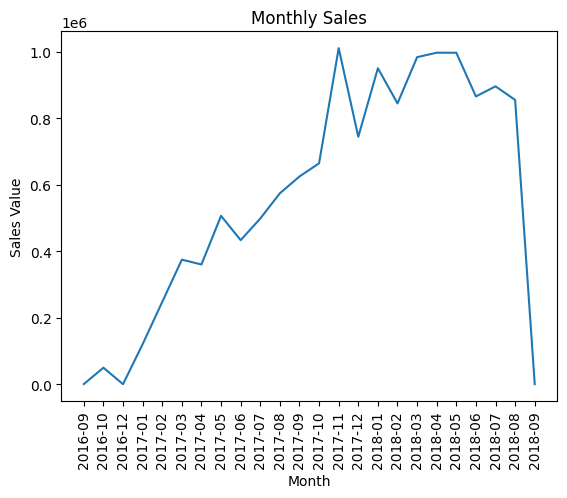

In [17]:
import matplotlib.pyplot as plt

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.xticks(rotation=90)

plt.show()

### Insight

- Sales generally increased as the marketplace expanded.
- The highest sales activity occurred during the later period of the dataset.
- Monthly sales showed some fluctuations throughout the observed period.